**Image segmentation** is the process of dividing an image into meaningful regions (e.g., foreground vs. background,
or object-specific regions). It's used in tasks like object detection, medical imaging, and autonomous driving.

Object Detection -- selective search
Semantic Segmentation -- Healthcare,Autonomous Driving

### Thresholding
**Simple Thresholding**
* Global Thresholding
A single threshold value (e.g., 127) is applied uniformly across the entire image.
Regions with intensity above the threshold are completely filled, as all pixels in those regions
share similar intensity levels.


**Adaptive Thresholding**
* Local Threholding
The threshold value is computed for smaller regions (blocks) of theimage based on the intensity of neighboring pixels.
Since the threshold dynamically adjusts based on the local intensity
patterns, it often highlights edges where there are rapid changes in pixel
intensity.

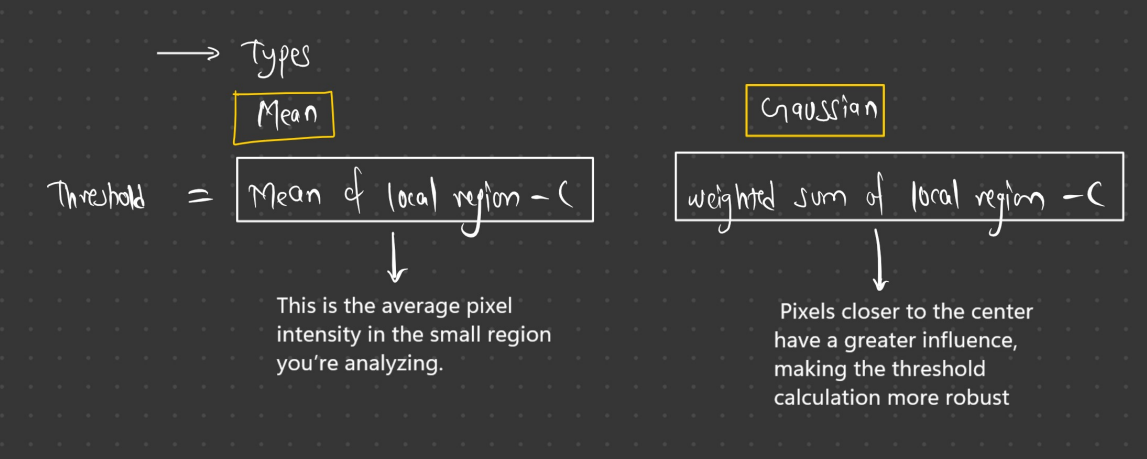





In [90]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

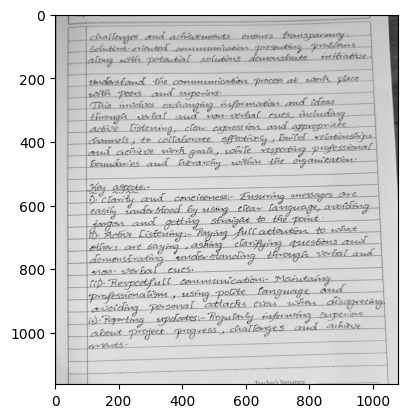

In [91]:
image = cv2.imread("asserts/img_seg.jpg")
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_image,cmap='gray')

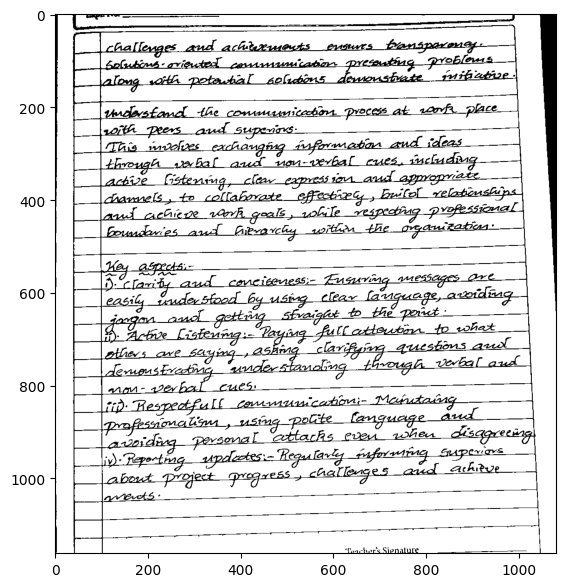

In [92]:
retval ,binary = cv2.threshold(gray_image,150,255,cv2.THRESH_BINARY)
plt.figure(figsize=(12,7))
plt.imshow(binary,cmap='grey')
plt.show()

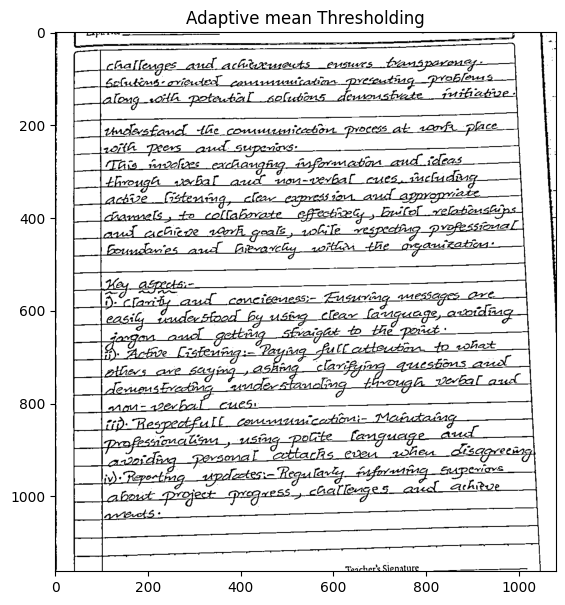

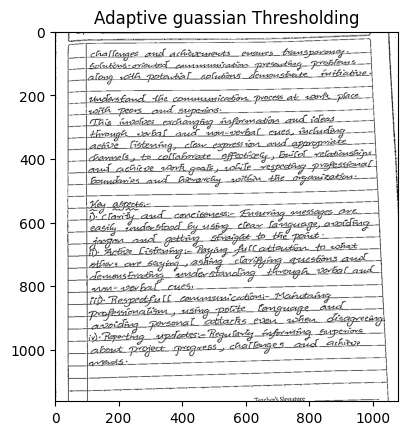

In [93]:
## Adaptive thresholding
adaptive_m = cv2.adaptiveThreshold(gray_image,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY,11,10)
adaptive_g = cv2.adaptiveThreshold(gray_image,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY,11,10)

plt.figure(figsize=(12,7))

plt.imshow(adaptive_m,cmap='grey')
plt.title("Adaptive mean Thresholding")
plt.show()

plt.imshow(adaptive_g,cmap='grey')
plt.title("Adaptive guassian Thresholding")
plt.show()

#### K-mean Clustering 
This algorithm groups pixels into clusters based on their intensity or color similarity.
1. Flatten the image into a 2D array (pixels and their intensities).
2. Specify the number of clusters (e.g., foreground, background).
3. Use the K-Means algorithm to group pixels into clusters.
4. Assign each cluster a specific label (or color).

In [94]:
image = cv2.imread("asserts/shapes.png")
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

pixel_values = image.reshape((-1,3))
pixel_values = np.float32(pixel_values)
print(pixel_values)

[[255. 255. 255.]
 [255. 255. 255.]
 [255. 255. 255.]
 ...
 [255. 255. 255.]
 [255. 255. 255.]
 [255. 255. 255.]]


In [95]:
criteria = (cv2.TERM_CRITERIA_EPS+cv2.TermCriteria_MAX_ITER,100,0.2)
k=3
_,labels,centers = cv2.kmeans(pixel_values,k,None,criteria,10,cv2.KMEANS_RANDOM_CENTERS)

In [96]:
print(labels.shape)
print(centers)

(337666, 1)
[[ 72.96779 112.36338 167.88632]
 [247.69833 116.68824  72.00107]
 [254.53096 254.20573 254.21095]]


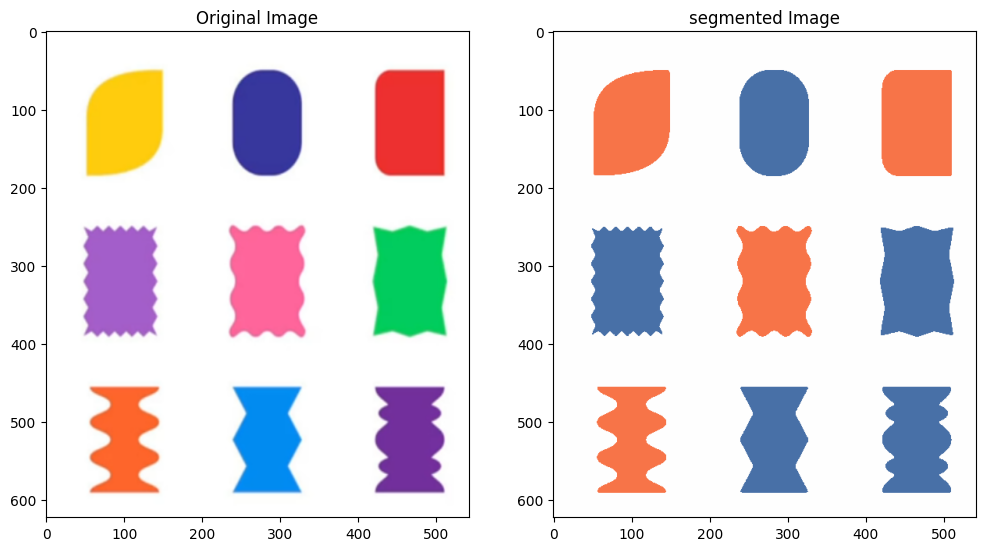

In [ ]:
centers = np.uint8(centers)
segmented_image = centers[labels.flatten()]
segmented_image = segmented_image.reshape(image.shape)

plt.figure(figsize=(12,7))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(segmented_image)
plt.title("segmented Image")

plt.show()

### Watershed Algarithm 
The Watershed Algorithm is used for image segmentation by treating pixel intensitieslike a topographic surface. It separates overlapping objects in an image by finding
watershed lines, which represent boundaries.


1. Convert the image to grayscale if it's in color.
2. Apply a binary threshold to create a binary image for separating foreground and
background.
3. Use morphological operations (e.g., cv2.morphologyEx) to
remove noise.
4. Compute the distance transform, which measures the distance from each
pixel to the nearest background pixel.
5. Label the foreground and background using markers.
6. Use the watershed function to compute the watershed lines.
7. Mark boundaries where watershed lines exist

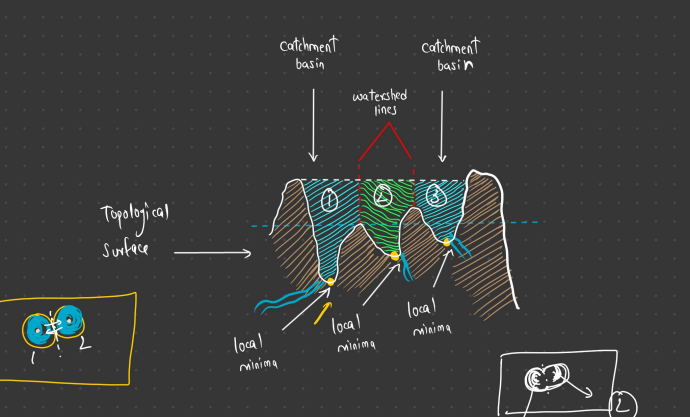

**Bright Pixels:** Represent "high" regions (like mountain peaks).

**Dark Pixels:** Represent "low" regions (like valleys).

**Gradients:** Represent slopes or edges, showing transitions between high and low areas.

Seed points represent different regions of interest. If we want to segment coins in an image. Coins will be seed
points.

When water from two regions meets, a boundary (watershed line) is formed.

### Understanding Watershed's "Boundary" Concept
* Imagine each seed point (markers) represents a specific object (e.g., the center of a coin) or the background.
* As the algorithm processes the image, it "floods" each region outward pixel by pixel.
* When pixels from two or more regions (e.g., two coins) meet, the algorithm determines that a boundary
exists between them.
* These "meeting points" conceptually form the watershed lines.

### Output of the Algorithm: Markers
* Each region identified is assigned a unique label (integer value) in the markers array.
amay
marken
* Pixels belonging to boundaries are labeled with a special value (commonly -1), indicating the watershed lines.
* The "boundaries" are not separate outputs. They are the pixels labeled -1 in the markers output.
* The final markers array represents the segmented image.
* The purpose of the Watershed Algorithm is not just to find boundaries but to assign labels to regions for
segmentation.
* This makes the output more useful for tasks like counting objects, measuring areas, or performing instance
segmentation.
* We can Visualize boundaries by highlighting -1 values.
* Visualize individual regions by isolating specific labels.

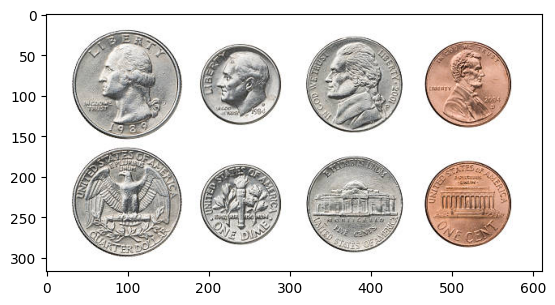

In [98]:
image = cv2.imread("asserts/coins.jpg")
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
original_image = image.copy()
plt.imshow(image)

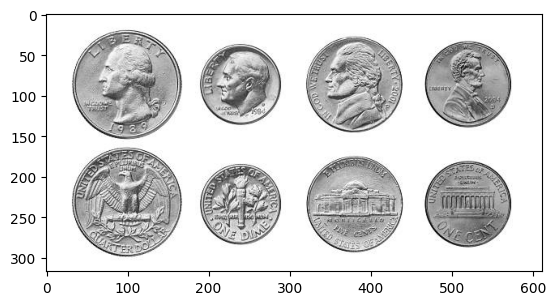

In [99]:
grey = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
plt.imshow(grey,cmap='grey')

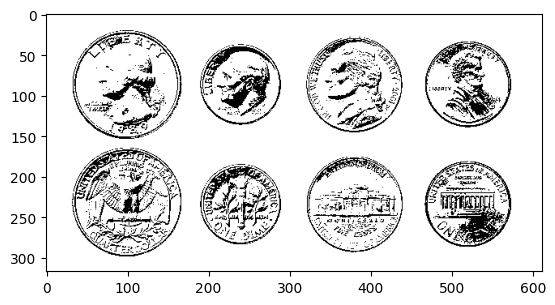

In [100]:
_,thresh = cv2.threshold(grey,130,255,cv2.THRESH_BINARY)
plt.imshow(thresh,cmap='grey')

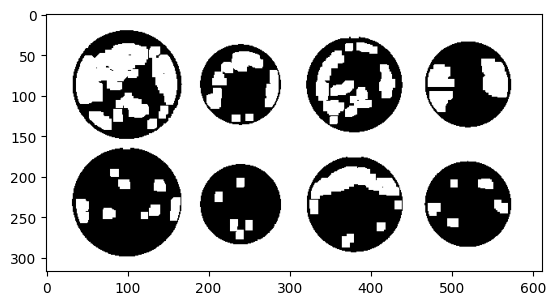

In [101]:
kernel = np.ones((3,3),np.uint8)
opening = cv2.morphologyEx(thresh,cv2.MORPH_OPEN,kernel,iterations=4)
plt.imshow(opening,cmap='grey')

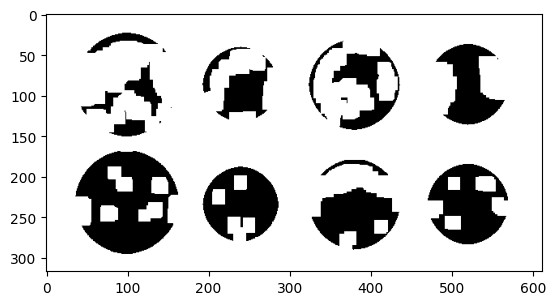

In [102]:
sure_bg = cv2.dilate(opening,kernel,iterations=3)
plt.imshow(sure_bg,cmap='grey')

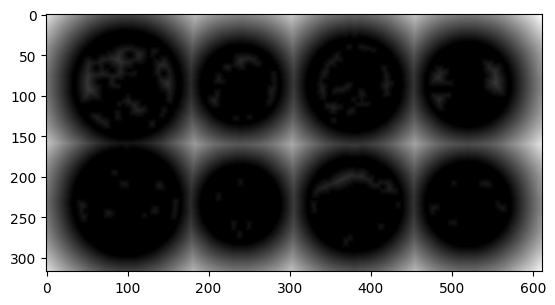

In [103]:
dist_transform= cv2.distanceTransform(opening,cv2.DIST_L2,5)
plt.imshow(dist_transform,cmap='grey')

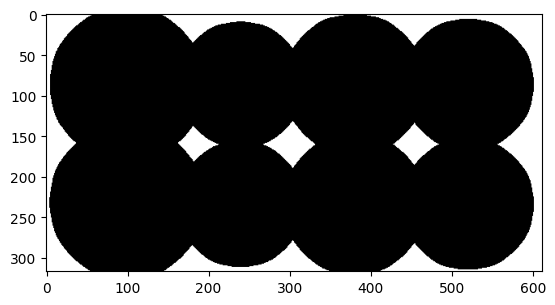

In [104]:
_,sure_fg = cv2.threshold(dist_transform,0.4*dist_transform.max(),255,0)
sure_fg = np.uint8(sure_fg)
plt.imshow(sure_fg,cmap='grey')

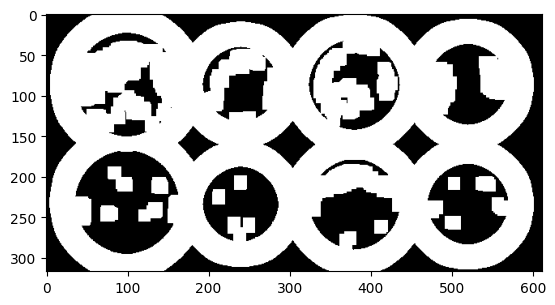

In [105]:
unknown = cv2.subtract(sure_bg,sure_fg)
plt.imshow(unknown,cmap='grey')

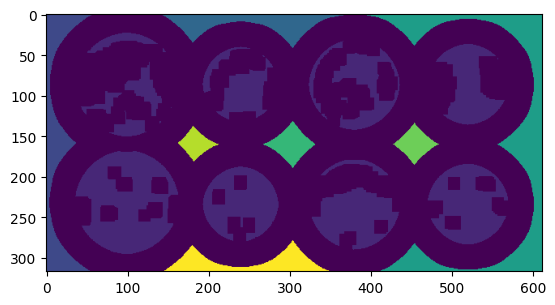

In [106]:
_,markers = cv2.connectedComponents(sure_fg)
markers = markers+1
markers[unknown==255] = 0

plt.imshow(markers)

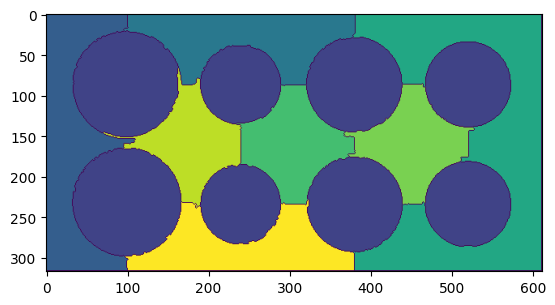

In [107]:
markers = cv2.watershed(image,markers)
plt.imshow(markers)

In [108]:
coin_mask = np.zeros_like(grey)
print(grey.shape)
print(coin_mask.shape)

unique_labels = np.unique(markers)

instance_number = 1
font = cv2.FONT_HERSHEY_SIMPLEX

for label in unique_labels:
    if label == 0 or label == -1:
        continue

    mask = np.uint8(markers == label)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) 

    for contour in contours: 
        area = cv2.contourArea(contour) 
        perimeter = cv2.arcLength(contour, True) 

        if perimeter == 0: 
            continue 

        circularity = 4 * np.pi * (area / (perimeter * perimeter)) 

        if 0.7 < circularity < 1.2 and area > 1000: 
            cv2.drawContours(original_image, [contour], -1, (0, 255, 0), 2) 
            x, y, w, h = cv2.boundingRect(contour) 
            cv2.putText(original_image, f'Coin {instance_number}', (x, y - 10), font, 0.6, (255, 0, 0), 2) 
            coin_mask = cv2.bitwise_or(coin_mask, mask) 
            cv2.rectangle(original_image, (x - 5, y - 5), (x + w + 5, y + h + 5), (160, 150, 250), 2)
            instance_number += 1


(317, 612)
(317, 612)


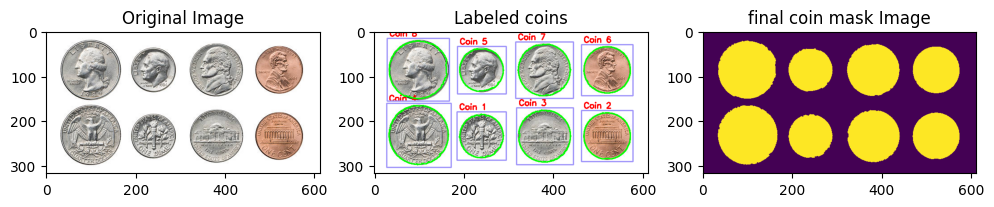

In [111]:
plt.figure(figsize=(12,7))
plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original Image")

plt.subplot(1,3,2)
plt.imshow(original_image)
plt.title("Labeled coins")


plt.subplot(1,3,3)
plt.imshow(coin_mask)
plt.title("final coin mask Image")

plt.show()